In [1]:
import pandas as pd

loan =pd.read_csv('/Users/Subham/Desktop/data/jupiternotebook/loan-data-set/loan_data.csv')

Goal:

Predict whether loan will be:

1 → Approved

0 → Rejected

# section 2 DATA UNDERSTANDING

In [2]:
import pandas as pd

loan =pd.read_csv('/Users/Subham/Desktop/data/jupiternotebook/loan-data-set/loan_data.csv')

print(loan.head())
print(loan.info())
print(loan.describe())

# Check missing values
print("\nMissing Values:\n", loan.isnull().sum())

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

#  section 3 Eda 

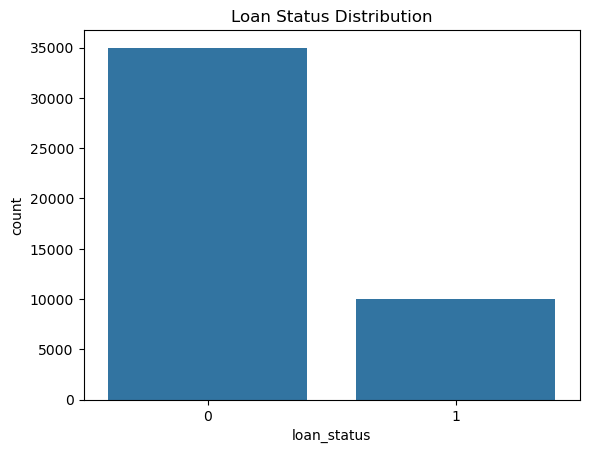

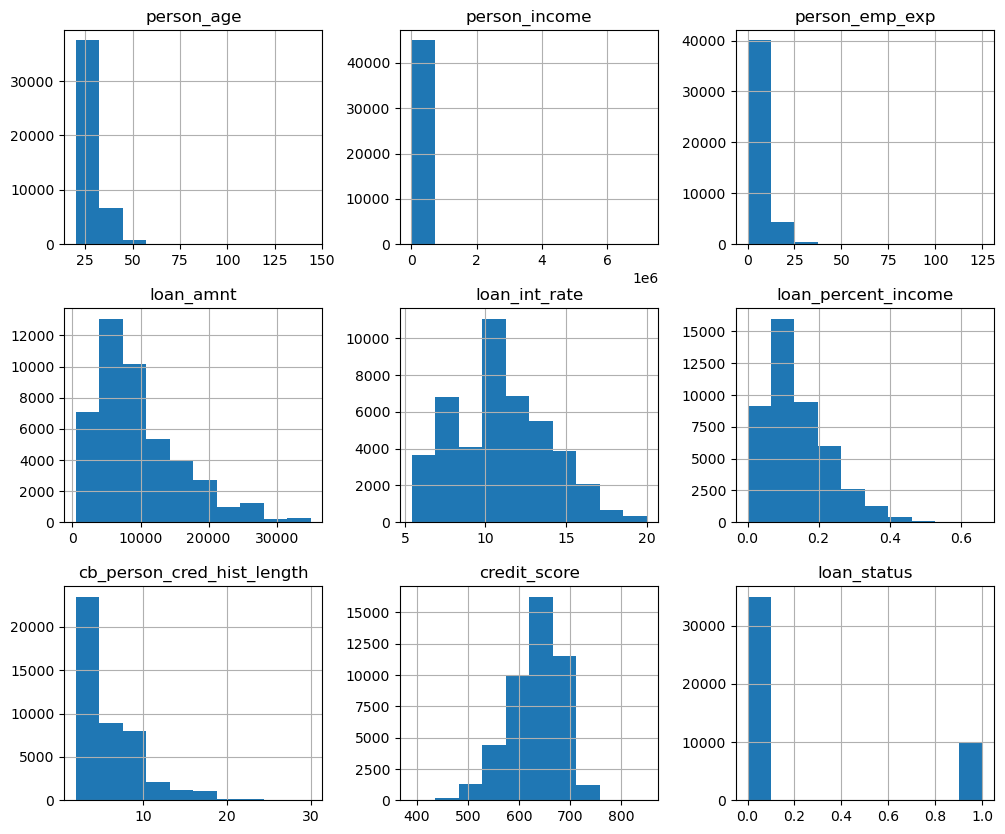

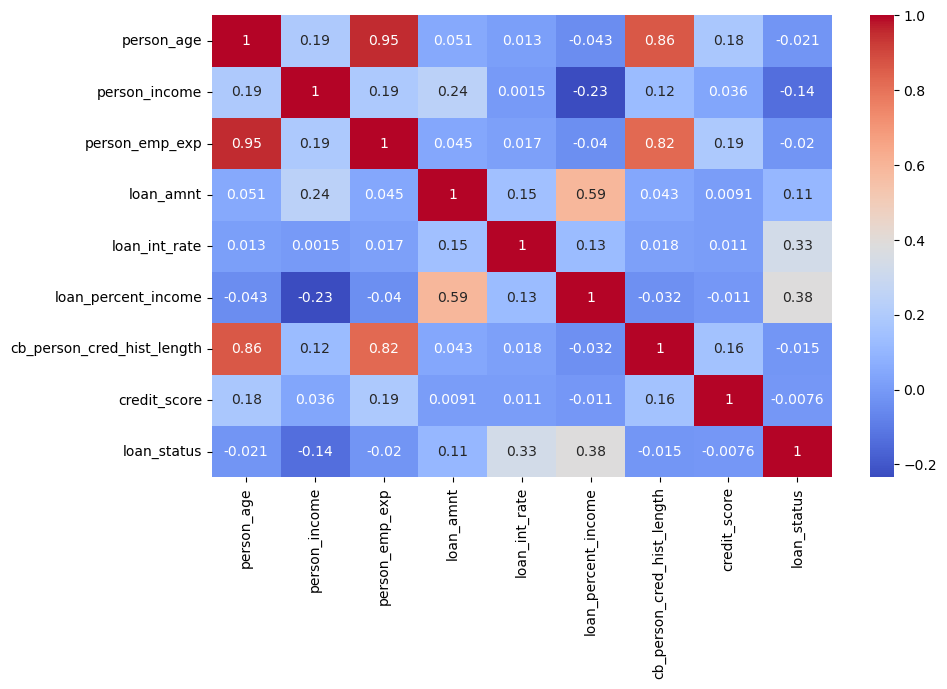

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='loan_status', data=loan)
plt.title("Loan Status Distribution")
plt.show()

# Numerical distributions
loan.hist(figsize=(12,10))
plt.show()

# Correlation
plt.figure(figsize=(10,6))
sns.heatmap(loan.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# 4. DATA PREPROCESSING

In [4]:
print("Gender:", loan['person_gender'].unique())
print("Education:", loan['person_education'].unique())
print("Home:", loan['person_home_ownership'].unique())
print("Loan Intent:", loan['loan_intent'].unique())
print("Default:", loan['previous_loan_defaults_on_file'].unique())

Gender: ['female' 'male']
Education: ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
Home: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
Loan Intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
Default: ['No' 'Yes']


In [5]:
#4.2
# Convert to string first (IMPORTANT)
for col in loan.select_dtypes(include='object').columns:
    loan[col] = loan[col].astype(str)

# Clean
for col in loan.select_dtypes(include='object').columns:
    loan[col] = loan[col].str.lower().str.strip()

In [6]:
# ECTION 4.3 — SAFE ENCODING (FIXED VERSION)
loan['person_gender'] = loan['person_gender'].replace({
    'male':0, 'female':1
})

loan['person_education'] = loan['person_education'].replace({
    'high school':0, 'associate':1, 'bachelor':2, 'master':3, 'doctorate':4
})

loan['person_home_ownership'] = loan['person_home_ownership'].replace({
    'rent':0, 'own':1, 'mortgage':2, 'other':3
})

loan['loan_intent'] = loan['loan_intent'].replace({
    'personal':0, 'education':1, 'medical':2,
    'venture':3, 'home improvement':4, 'debt consolidation':5
})

loan['previous_loan_defaults_on_file'] = loan['previous_loan_defaults_on_file'].replace({
    'no':0, 'yes':1
})

/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_5557/1483749155.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan['person_gender'] = loan['person_gender'].replace({
/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_5557/1483749155.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan['person_education'] = loan['person_education'].replace({
/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_5557/1483749155.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed

In [7]:
#SECTION 4.4 — HANDLE UNKNOWN VALUES (CRITICAL)
# Convert everything to numeric safely
loan = loan.apply(pd.to_numeric, errors='ignore')

# Check missing again
print(loan.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


/var/folders/9_/g2qlrkl10czg32v2f2n8lbnh0000gn/T/ipykernel_5557/3419524741.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  loan = loan.apply(pd.to_numeric, errors='ignore')


# 5. FEATURE ENGINEERING

In [8]:
# Recalculate (important for consistency)
loan['loan_percent_income'] = loan['loan_amnt'] / loan['person_income']

# 6. FEATURE SELECTION

In [9]:
features = [
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'credit_score',
    'previous_loan_defaults_on_file',
    'person_emp_exp',              # 🔥 ADD
    'cb_person_cred_hist_length'   # 🔥 ADD
]

X = loan[features]
y = loan['loan_status']

# 7. TRAIN-TEST SPLIT

In [10]:
from sklearn.model_selection import train_test_split

print(y.value_counts())  # check imbalance

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 IMPORTANT
)

loan_status
0    35000
1    10000
Name: count, dtype: int64


# 8. SCALING (CRITICAL)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9. MODEL BUILDING

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',   # 🔥 fixes imbalance
        random_state=42
    ),
    param_rf,
    cv=5,
    scoring='f1'
)

grid_rf.fit(X_train, y_train)

final_model = grid_rf.best_estimator_

print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


# 10 Model Evaluation

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = final_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8848888888888888

Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92      7000
           1       0.68      0.91      0.78      2000

    accuracy                           0.88      9000
   macro avg       0.83      0.89      0.85      9000
weighted avg       0.91      0.88      0.89      9000


Confusion Matrix:
 [[6154  846]
 [ 190 1810]]


# 12 sample prediction

In [17]:
print(y.value_counts())

loan_status
0    35000
1    10000
Name: count, dtype: int64


In [ ]:
import joblib

joblib.dump(final_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

In [18]:
print(final_model.predict_proba(X_test[:10]))

[[0.75412866 0.24587134]
 [0.98939613 0.01060387]
 [0.98947105 0.01052895]
 [0.99755635 0.00244365]
 [0.15224393 0.84775607]
 [0.35643793 0.64356207]
 [0.76984089 0.23015911]
 [0.99211322 0.00788678]
 [0.46892132 0.53107868]
 [0.57078694 0.42921306]]


In [19]:
print(final_model.predict_proba(X_test[:5]))

[[0.75412866 0.24587134]
 [0.98939613 0.01060387]
 [0.98947105 0.01052895]
 [0.99755635 0.00244365]
 [0.15224393 0.84775607]]
